# Motor Insurance Pricing — Data Exploration

**Dataset:** French Motor Third-Party Liability (freMTPL2freq / freMTPL2sev)

**Goal of this notebook:** This notebook explores the French Motor Third-Party Liability dataset to understand:
- The structure of the data
- The distribution of claims
- Potential risk factors affecting claim frequency
- Data quality issues before modelling

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

DATA_DIR = "../data/raw"

## 1. Loading data and Initial Interpretations

Load both the frequency and severity tables, check their shape, dtypes, and how they relate via `IDpol`.

In [2]:
freq = pd.read_csv(f"{DATA_DIR}/freMTPL2freq.csv")
sev = pd.read_csv(f"{DATA_DIR}/freMTPL2sev.csv")

print("freq shape:", freq.shape)
print("sev shape:", sev.shape)

freq shape: (678013, 12)
sev shape: (26639, 2)


In [5]:
freq.head()

,IDpol,ClaimNb,Exposure,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Area,Density,Region
0,1.0,1,0.10,5,0,55,50,B12,Regular,D,1217,Rhone-Alpes
1,3.0,1,0.77,5,0,55,50,B12,Regular,D,1217,Rhone-Alpes
2,5.0,1,0.75,6,2,52,50,B12,Diesel,B,54,Picardie
3,10.0,1,0.09,7,0,46,50,B12,Diesel,B,76,Aquitaine
4,11.0,1,0.84,7,0,46,50,B12,Diesel,B,76,Aquitaine


In [4]:
freq.info()

<class 'pandas.DataFrame'>
RangeIndex: 678013 entries, 0 to 678012
Data columns (total 12 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   IDpol       678013 non-null  float64
 1   ClaimNb     678013 non-null  int64  
 2   Exposure    678013 non-null  float64
 3   VehPower    678013 non-null  int64  
 4   VehAge      678013 non-null  int64  
 5   DrivAge     678013 non-null  int64  
 6   BonusMalus  678013 non-null  int64  
 7   VehBrand    678013 non-null  str    
 8   VehGas      678013 non-null  str    
 9   Area        678013 non-null  str    
 10  Density     678013 non-null  int64  
 11  Region      678013 non-null  str    
dtypes: float64(2), int64(6), str(4)
memory usage: 62.1 MB


In [6]:
sev.head()

,IDpol,ClaimAmount
0,1552,995.20
1,1010996,1128.12
2,4024277,1851.11
3,4007252,1204.00
4,4046424,1204.00


In [7]:
sev.info()

<class 'pandas.DataFrame'>
RangeIndex: 26639 entries, 0 to 26638
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   IDpol        26639 non-null  int64  
 1   ClaimAmount  26639 non-null  float64
dtypes: float64(1), int64(1)
memory usage: 416.4 KB


In [8]:
# How many policies in freq actually have a matching claim record in sev?
matched = sev["IDpol"].isin(freq["IDpol"]).sum()
print(f"{matched} / {len(sev)} severity rows match a policy in frequency")

26444 / 26639 severity rows match a policy in frequency


#### Findings: 
- **Frequency** dataset contains policy-level information and the number of claims made.  
- **Severity** dataset contains information about the cost of individual claims.  
  
- The frequency dataset consists of **678013** rows and **12** columns 
- The severity dataset consists of **26639** rows and **2** columns   
   
The columns for the frequency and severity datasets are explained in the *CASdatasets Manual* (see README) and highlighted below as well as their data types:  
   
Frequency:  
- **IDpol** (float): The policy ID (used to link with the claims dataset). 
- **ClaimNb** (integer): Number of claims during the exposure period. 
- **Exposure** (float): The period of exposure for a policy, in years. 
- **VehPower** (integer) The power of the car (ordered values). 
- **VehAge** (integer): The vehicle age, in years. 
- **DrivAge** (integer): The driver age, in years. 
- **BonusMalus** (integer): Bonus/malus, between 50 and 350: <100 means bonus, >100 means malus in France. 
- **VehBrand** (string): The car brand (unknown categories)
- **VehGas** (string): The car gas, Diesel or regular
- **Area** (string): The density value of the city community where the car driver lives in: from "A" for rural area to "F" for urban centre
- **Density** (integer): The density of inhabitants (number of inhabitants per square-kilometer) of the city where the car driver lives in
- **Region** (string): The policy region in France (based on the 1970-2015 classification)  
  
Severity:  
- **IDpol** (integer): The occurence date (used to link with the contract dataset).
- **ClaimAmount** (float): The cost of the claim, seen as at a recent date.  
  
**195 claims** (~0.732% of severity records) reference a policy ID not present in the frequency table — a known inconsistency in this dataset. These will be excluded from the frequency-severity join going forward as it is less than 1% of claims.


## 2. Data quality

Check for missing values, duplicates, and implausible ranges, for example the ages of the drivers should be sensible.

In [ ]:
print("Missing values (freq):")
print(freq.isnull().sum())
print("\nDuplicate IDpol rows:", freq["IDpol"].duplicated().sum())

Missing values (freq):
IDpol         0
ClaimNb       0
Exposure      0
VehPower      0
VehAge        0
DrivAge       0
BonusMalus    0
VehBrand      0
VehGas        0
Area          0
Density       0
Region        0
dtype: int64

Duplicate IDpol rows: 0


In [21]:
print("Missing values (sev):")
print(sev.isnull().sum())
print("\nDuplicate IDpol rows:", sev["IDpol"].duplicated().sum())
print("Fully duplicated rows (sev):", sev.duplicated().sum())

Missing values (sev):
IDpol          0
ClaimAmount    0
dtype: int64

Duplicate IDpol rows: 1689
Fully duplicated rows (sev): 255


##### Findings:

- There are no missing values in both the severity and frequency datasets. This is expected as both datasets are curated academic datasets and not raw scraped data.  
  
- There are no duplicate IDpol rows in the frequency dataset however there are 1689 duplicate IDpol rows in the severity dataset. This refers to how in the frequency dataset, each row is one policy so a duplicate IDpol there would mean that the same policy was logged twice which is the result of a genuine data issue and something to be explored further. In the severity dataset, each row is one claim rather than one policy. A single policy can have multiple claims, for example, a driver who had two separate accidents. Therefore, the duplicate IDpol rows is not a data issue and likely expected in the severity dataset, it simply shows a figure related to claim recurrence.
    
- However, there are 255 fully duplicated rows in the severity dataset. This means there are 255 entries which are exactly the same in the dataset, which while possible, is unlikely for this number of entries. It is more likely for this to be a data logging error where the same claim was recorded twice. This deserves further examination.


In [25]:
dupes = sev[sev.duplicated(keep=False)]
dupes.sort_values("IDpol").head(20)

,IDpol,ClaimAmount
5022,18698,1128.12
6355,18698,1128.12
4521,19887,1128.12
4514,19887,1128.12
6318,24992,1128.12
6322,24992,1128.12
5866,25763,1128.12
5862,25763,1128.12
24094,29567,1128.12
24096,29567,1128.12


In [29]:
sev["ClaimAmount"].value_counts().head(10)

ClaimAmount
1204.00    4792
1128.12    3056
1172.00    2072
1128.00     831
602.00      433
1320.00     175
556.14      155
586.00      104
1500.00     103
564.06       94
Name: count, dtype: int64

In [ ]:

dupes.groupby("ClaimAmount")["IDpol"].nunique().sort_values(ascending=False).head(10)

ClaimAmount
1204.00     101
1128.12      64
1172.00      48
1500.00       8
1128.00       4
10000.00      3
1000.00       2
69.51         1
75.00         1
660.00        1
Name: IDpol, dtype: int64

##### Findings:

This examination yielded very interesting results. It seems that throughout the database there are specific values that repeat an unusually large number of times, for example 1204.00 appears 4,792 times, 1128.12 appears 3,056 times and 1172.00 appears 2,072 times. This leads me to believe that despite the duplicate rows initally appearing to be a logging issue (and thus something to be dropped) that instead in this dataset there exists specific values that act as standardized flat payout amounts. Instead of every claim being a unique, freely-varying cost, many follow fixed schedules. Thus in the severity dataset, with thousands of claims sharing these common flat amounts, some will coincidentally also share the same IDpol twice. As this dataset consists of only these two columns, it's not possible to conclusively distinguish true duplicate logging from two genuinely separate claims of the same flat amount, however in the *CASdatasets Manual* it is stated that "Some claim amounts of freMTPL2sev are fixed claim amounts based on the French IRSA-IDA claim convention". Given this, I will choose to keep these columns.

In [10]:
freq.describe()

,IDpol,ClaimNb,Exposure,VehPower,VehAge,DrivAge,BonusMalus,Density
count,6.780130e+05,678013.000000,678013.000000,678013.000000,678013.000000,678013.000000,678013.000000,678013.000000
mean,2.621857e+06,0.053247,0.528750,6.454631,7.044265,45.499122,59.761502,1792.422405
std,1.641783e+06,0.240117,0.364442,2.050906,5.666232,14.137444,15.636658,3958.646564
min,1.000000e+00,0.000000,0.002732,4.000000,0.000000,18.000000,50.000000,1.000000
25%,1.157951e+06,0.000000,0.180000,5.000000,2.000000,34.000000,50.000000,92.000000
50%,2.272152e+06,0.000000,0.490000,6.000000,6.000000,44.000000,50.000000,393.000000
75%,4.046274e+06,0.000000,0.990000,7.000000,11.000000,55.000000,64.000000,1658.000000
max,6.114330e+06,16.000000,2.010000,15.000000,100.000000,100.000000,230.000000,27000.000000


- The **count** value matches the earlier finding of no missing values, the data is consistent.
- The maximum **Exposure** is listed as 2.01. This would refer to a policy lasting longer than a year. While unlikely, this is expected as in the *CASdatasets Manual* it is stated that the policies are observed "mostly on one year".
- **VehPower**: Minimum of 4 and maximum of 15 is consistent with the power of the car being represented by ordered values.
- The maximum for **VehAge** is 100. This is alarming as this would mean a 100 year old car is actively insured which is implausible. It is very likely to be a data entry artifact or an intentional cap used in the original dataset rather than a real vehicle age. Deserves further examination.
- The maximum for **DrivAge** is 100, this is unlikely but plausible but still deserves further looking into.
- **BonusMalus**: min 50, max 230 — consistent with the real French bonus-malus scale (typically 50–350), so this looks fine.
- **Density**: Maximum of 27,000, a large spread is expected here (rural vs. dense urban areas) however this is not necessarily a problem, just heavily skewed. I will likely view it on a log scale when I plot it.


In [3]:
freq["VehAge"].value_counts().sort_index(ascending=False).head(15)

VehAge
100    25
99     23
85      1
84      1
83      2
82      1
81      3
80      3
79      1
78      1
76      1
71      1
70      3
69      4
68      2
Name: count, dtype: int64

In [4]:
freq["DrivAge"].value_counts().sort_index(ascending=False).head(15)

DrivAge
100      3
99      70
98       5
97      10
96      15
95      24
94      32
93      55
92      66
91     121
90     167
89     198
88     229
87     280
86     319
Name: count, dtype: int64

##### Findings:
Vehicle Age shows an unnatural gap: There's a large collection of values at 100 (n=25) and 99 (n=23) but nothing between 86 and 90, as the data jumps directly to age 85. This pattern suggests 100 (and likely 99) is a capped or placeholder value rather than a genuine vehicle age. Driver Age is largely smooth and consistent with a real driver population, however similarly to vehicle age there is a steep increase in values for age 99 (n=70) comapared to ages 98 (n=5) and 100 (n=3), suggesting DrivAge may also be top-coded at 99 for very elderly drivers. Both will be treated as open-ended top categories (e.g. '90+') rather than precise ages in later analysis.

In [22]:
sev.describe()

,IDpol,ClaimAmount
count,2.663900e+04,2.663900e+04
mean,2.279864e+06,2.278536e+03
std,1.577202e+06,2.929748e+04
min,1.390000e+02,1.000000e+00
25%,1.087642e+06,6.868100e+02
50%,2.137413e+06,1.172000e+03
75%,3.180162e+06,1.228080e+03
max,6.113971e+06,4.075401e+06


##### Findings:
  
Claim severity is heavily right-skewed: the mean (€2,278.54) is roughly double the median (€1,172.00), and the maximum claim (€4,075,401) is over 3,000x the median. This is consistent with typical insurance claim behaviour, where the majority of claims are modest but a small number of large claims dominate total cost. The median claim amount (€1,172.00) also aligns with the standardized IRSA-IDA flat payout amounts identified earlier. For this reason, I will likely explore using a distribution like Gamma or Lognormal rather than assuming a normal distribution.

In [ ]:
freq.duplicated().sum() #To match with earlier check of duplicate rows, this should be 0

np.int64(0)

In [30]:
sev.duplicated().sum() #To match with earlier check of duplicate rows, this should be 255

np.int64(255)

In [19]:
freq.nunique()

IDpol         678013
ClaimNb           11
Exposure         181
VehPower          12
VehAge            78
DrivAge           83
BonusMalus       115
VehBrand          11
VehGas             2
Area               6
Density         1607
Region            21
dtype: int64

##### Findings:

VehAge has only 78 distinct values despite spanning a theoretical range of 0–100 (101 possible integers), confirming that values in the 86–98 range are genuinely absent from the data. In contrast, DrivAge has exactly 83 distinct values across its 18–100 range (83 possible integers), meaning every age is represented; the earlier spike at 99 reflects a distributional distortion (likely top-coding) rather than missing values in the range.

In [11]:
# Sanity checks
print("Exposure out of [0,1]:", ((freq["Exposure"] < 0) | (freq["Exposure"] > 1)).sum())
print("DrivAge range:", freq["DrivAge"].min(), "-", freq["DrivAge"].max())
print("VehAge range:", freq["VehAge"].min(), "-", freq["VehAge"].max())

Exposure out of [0,1]: 1224
DrivAge range: 18 - 100
VehAge range: 0 - 100


## 3. Univariate analysis

Distributions of the target(s) and key features one at a time.

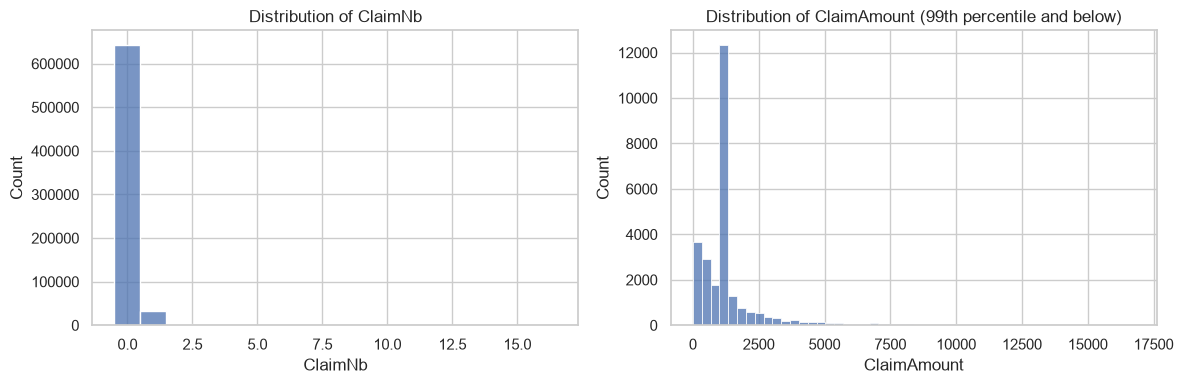

In [ ]:
xlim_val = sev["ClaimAmount"].quantile(0.99)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(freq["ClaimNb"], discrete=True, ax=axes[0])
axes[0].set_title("Distribution of ClaimNb")

sns.histplot(sev[sev["ClaimAmount"] <= xlim_val]["ClaimAmount"], bins=50, ax=axes[1])
axes[1].set_title("Distribution of ClaimAmount (99th percentile and below)") #This is added as otherwise the plot is dominated by the extreme values due to a bin width bug
plt.tight_layout()

##### Findings:

ClaimNb confirms claim occurrence is rare: the overwhelming majority of policies have zero claims. ClaimAmount is heavily right-skewed even after excluding the top 1% of values — a large spike near €1,000-1,500 likely reflects the standardized IRSA-IDA flat payout amounts I identified earlier, with a smaller cluster of low-value claims below €500 and a long tail extending past €5,000.

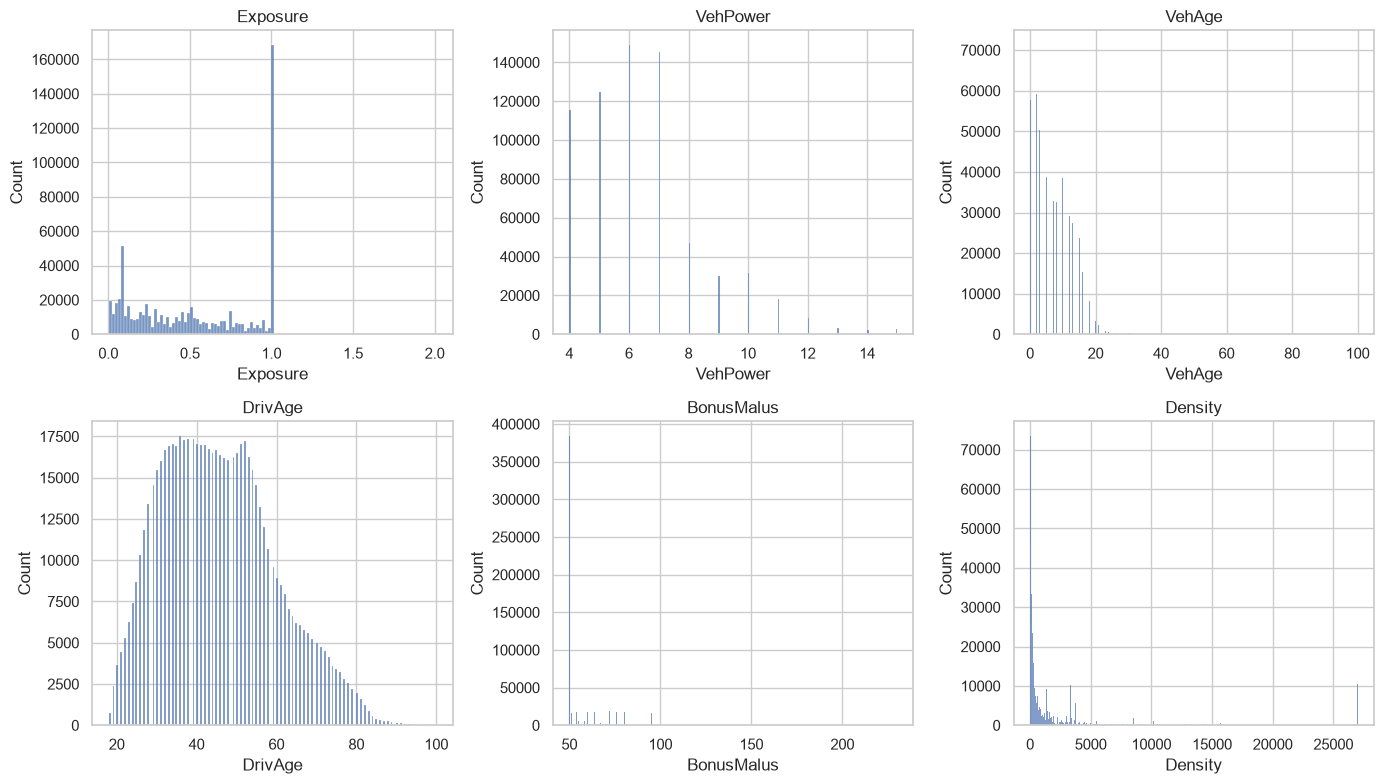

In [6]:
numeric_cols = ["Exposure", "VehPower", "VehAge", "DrivAge", "BonusMalus", "Density"]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.flat, numeric_cols):
    sns.histplot(freq[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()

##### Findings:

- Exposure shows a strong concentration at 1.0 (full-year policies), with partial-year exposures spread thinly across the rest of the range. 
- VehPower reflects the relative popularity of specific power ratings rather than a true continuous skew. 
- VehAge and DrivAge both taper with age, though DrivAge shows a smooth, genuinely bell-shaped population distribution while VehAge shows the capped/gapped behavior identified in the data quality section. 
- BonusMalus and Density are both heavily right-skewed, dominated by their minimum values (best driving record; low-density areas), with long thin tails — both will likely benefit from a log transform in later analysis.

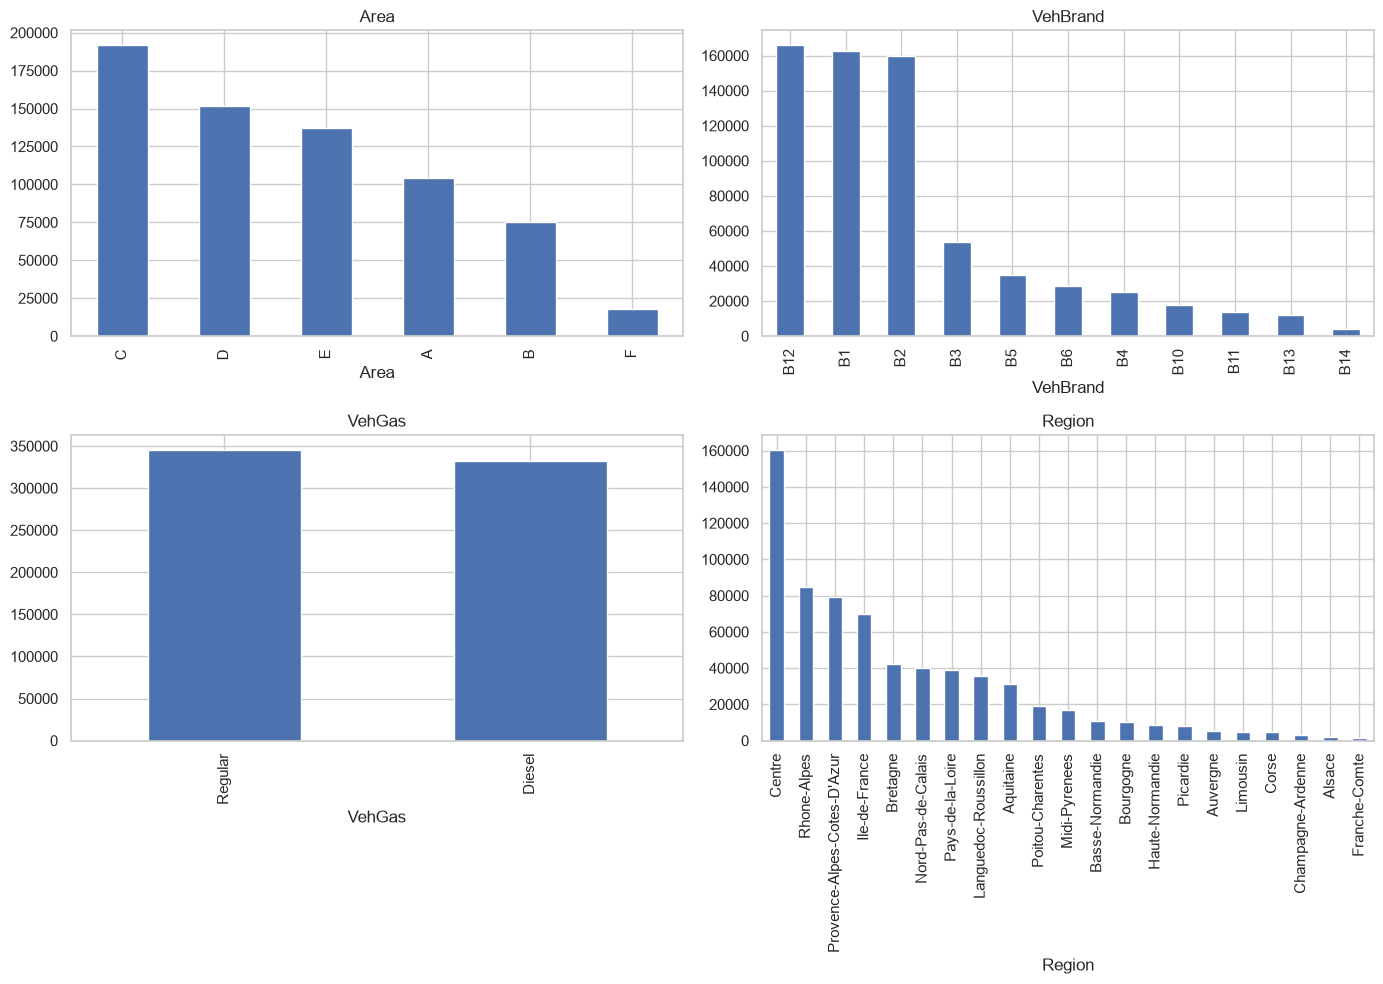

In [7]:
categorical_cols = ["Area", "VehBrand", "VehGas", "Region"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, col in zip(axes.flat, categorical_cols):
    freq[col].value_counts().plot(kind="bar", ax=ax)
    ax.set_title(col)
plt.tight_layout()

*Findings: (which features are skewed, which categories dominate, anything surprising.)*

## 4. Bivariate analysis

How claim frequency and severity vary with key features.

In [ ]:
freq["DrivAgeBand"] = pd.cut(freq["DrivAge"], bins=[18, 25, 35, 45, 55, 65, 100])

band_summary = freq.groupby("DrivAgeBand", observed=True).agg(
    claim_nb=("ClaimNb", "sum"),
    exposure=("Exposure", "sum")
)
band_summary["frequency"] = band_summary["claim_nb"] / band_summary["exposure"]
band_summary["frequency"].plot(kind="bar", figsize=(8, 4), title="Claim frequency by driver age band")
plt.ylabel("Claims per unit exposure")
plt.tight_layout()

In [ ]:
region_summary = freq.groupby("Region", observed=True).agg(
    claim_nb=("ClaimNb", "sum"),
    exposure=("Exposure", "sum")
)
region_summary["frequency"] = region_summary["claim_nb"] / region_summary["exposure"]
region_summary["frequency"].sort_values().plot(kind="barh", figsize=(8, 6), title="Claim frequency by region")
plt.xlabel("Claims per unit exposure")
plt.tight_layout()

*Findings: (which features look like real risk drivers vs noise.)*

## 5. Correlations

Check for multicollinearity among numeric features.

In [ ]:
corr = freq[numeric_cols].corr()
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation matrix — numeric features")
plt.tight_layout()

*Findings: (note any strongly correlated pairs, e.g. DrivAge vs BonusMalus, and what that implies for modeling later.)*

## 6. Exposure-aware frequency

Reminder: `Exposure` is the fraction of the year a policy was active. Always compute `ClaimNb / Exposure` (or aggregate sums as above) rather than comparing raw claim counts across policies with different exposure — otherwise short-exposure policies look artificially safe or risky.

In [ ]:
overall_frequency = freq["ClaimNb"].sum() / freq["Exposure"].sum()
print(f"Overall portfolio claim frequency: {overall_frequency:.4f} claims per policy-year")

## 7. Summary of findings

*(Write a short recap here: what stood out, which features look predictive, any data quality issues to address in the next notebook, and what you'll do next — e.g. cleaning, encoding, and building frequency/severity models.)*